# 03 — Hand-crafted NDVI baselines

This notebook builds the simple, non-deep-learning NDVI baselines that Geo-SimCLR has to beat.

**Purpose / inputs / outputs / runtime**

- **Purpose:** compute proper per-pixel NDVI from CropNet's quantized B04 + B08 channels, aggregate to per-(county, biweek) and per-(county, year) features, then fit and report six NDVI / state+year LightGBM (or Ridge) yield baselines under both temporal and spatial generalization splits.
- **Inputs:** the parquets and raw NDVI HDF5s produced by `02_acquire_data.ipynb` (in particular `data/processed/county_index.parquet`, `data/processed/yield_county_year.parquet`, and the per-state NDVI files under `data/raw/cropnet/Sentinel-2 Imagery/data/NDVI/`).
- **Outputs:** `biweekly_ndvi.parquet`, `baseline_features.parquet`, `phen_stage_lookup.parquet` in `data/processed/`, and `baseline_yield_results.parquet` in `results/tables/`.
- **Runtime:** CPU only. Most of the time is spent walking the NDVI HDF5 files (~10 s per file on SSD; about 15 minutes total at the 7-state scope).

**A note on the NDVI tiles.** An earlier draft of this notebook computed NIR / NDWI / SWIR indices from the AG raw bands as a workaround, based on the (incorrect) belief that CropNet's "NDVI" tiles were just an RGB visualization. They are not — they store quantized **B04 (Red) + B08 (NIR)** as `uint8` with about five reflectance levels per channel. We therefore recover proper per-pixel NDVI directly:

$$\text{NDVI} \;=\; \frac{B08 - B04}{B08 + B04 + \varepsilon} \;=\; \frac{\text{Ch}_1 - \text{Ch}_0}{\text{Ch}_1 + \text{Ch}_0 + \varepsilon} \;\in\;[-1,\,+1].$$

The five-level quantization gives only ~25 distinct values per pixel post-ratio, but mean-pooling at the county level (~10k+ pixels per county-biweek) washes most of this out. The same precision floor applies uniformly to every NDVI-based baseline, so the comparison stays fair.

**What this notebook produces (three baseline feature sets for `05_extract_and_probe.ipynb`)**

1. **Peak-NDVI scalar** — one number per (county, year), the mean NDVI over the (Aug 1, Aug 15) biweeks. The textbook single-feature remote-sensing yield baseline (Hatfield et al.\ 2008 reports peak-NDVI ↔ corn-yield Pearson r ≈ 0.5–0.7 in the right setting).
2. **Biweekly-NDVI series** — twelve numbers per (county, year), the mean NDVI per biweek over Apr–Sep. A stronger LightGBM time-series comparator.
3. **Phenological-stage feature** — `phen_stage[(state, biweek)] ∈ [-0.2, 1.2]` derived from USDA reference planting / harvest dates, for cross-state alignment in `04_geosimclr.ipynb`.

**Outputs on disk**

| File | Schema | Used by |
|---|---|---|
| `data/processed/biweekly_ndvi.parquet` | `(state, fips, year, biweek, ndvi_mean, ndvi_std, n_grids, n_pixels)` | `05_extract_and_probe.ipynb`, `06_visualize.ipynb` |
| `data/processed/baseline_features.parquet` | `(fips, year, peak_ndvi, growing_ndvi_mean, growing_ndvi_max, growing_ndvi_std, ...)` joined with corn-yield labels | `05_extract_and_probe.ipynb` |
| `data/processed/phen_stage_lookup.parquet` | `(state, biweek_md, biweek_doy, phen_stage)` | `04_geosimclr.ipynb` |
| `results/tables/baseline_yield_results.parquet` | one row per (baseline, split) | `05_extract_and_probe.ipynb`, `09_results.ipynb` |

In [1]:
"""
Cell 1 — Imports + config.
"""
import os
from pathlib import Path
from datetime import date, timedelta
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = ROOT / "data" / "raw" / "cropnet"
DATA_PROC = ROOT / "data" / "processed"

# Outputs
BIWEEKLY_NDVI_PATH = DATA_PROC / "biweekly_ndvi.parquet"
BASELINE_PATH = DATA_PROC / "baseline_features.parquet"
PHEN_STAGE_PATH = DATA_PROC / "phen_stage_lookup.parquet"

# Inputs
COUNTY_INDEX_PATH = DATA_PROC / "county_index.parquet"
YIELD_PATH = DATA_PROC / "yield_county_year.parquet"
CRD_PATH = DATA_PROC / "crd_lookup.parquet"

# CropNet NDVI HDF5 channel layout (Ch0 = B04 Red, Ch1 = B08 NIR; recovered NDVI = (Ch1 - Ch0) / (Ch1 + Ch0)):
#   Ch0 = B04 (Red)        — uint8, quantized to ~5 levels {0, 51, 102, 154, 204, 255}
#   Ch1 = B08 (NIR)        — uint8, quantized
#   Ch2 = (auxiliary, not used; possibly NDVI-derived colormap channel)
#
# Proper NDVI = (Ch1 - Ch0) / (Ch1 + Ch0). Range [-1, +1]. Vegetation ≈ +0.5 to +0.8.
NDVI_BAND_RED = 0
NDVI_BAND_NIR = 1

print("ROOT      :", ROOT)
print("DATA_RAW  :", DATA_RAW)
print("DATA_PROC :", DATA_PROC)
print()

for p in [COUNTY_INDEX_PATH, YIELD_PATH, CRD_PATH]:
    assert p.exists(), f"Missing required input from notebook 02: {p}"
print("All required inputs from notebook 02 are present.")

ROOT      : d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial
DATA_RAW  : d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\data\raw\cropnet
DATA_PROC : d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\data\processed

All required inputs from notebook 02 are present.


## 1. Sanity-check the NDVI tile encoding

Before computing baselines, confirm:

1. NDVI HDF5 files have shape `(G, 224, 224, 3)` `uint8`.
2. Pixel values are quantized to ~5 reflectance levels (a CropNet design choice for storage efficiency).
3. `ndvi = (Ch1 - Ch0) / (Ch1 + Ch0)` produces a sensible distribution: range [-1, +1], mean around +0.4-0.5 in August Iowa, with most pixels in [0.4, 0.8].

### Why the histogram has gaps (zero observations in some bins) — expected, not a bug

Because Red and NIR channels are each quantized to ~5 levels in `{0, 51, 102, 154, 204, 255}`, the resulting NDVI = (NIR-Red)/(NIR+Red) takes only a small set of discrete values. For example, the (Red, NIR) pairs that actually occur often in healthy August corn give:

| (Red, NIR) | NDVI | Bin |
|---|---|---|
| (0, 0) | -1 (epsilon, no-data) | [-1.0, -0.8) |
| (51, 204) | 0.60 | [0.4, 0.6) |
| (51, 255) | 0.67 | [0.6, 0.8) |
| (0, 204) | 1.0 | [0.8, 1.0) |
| (102, 204) | 0.33 | [0.2, 0.4) — but rare for canopy |
| (51, 102) | 0.33 | [0.2, 0.4) — rare for canopy |

Many `[a, b)` bins land between two adjacent quantization steps and have zero pixels because no `(Red, NIR)` pair maps there. **County-level mean-pooling washes most of this out** — county means take continuous values across 600k+ pixels.

**Limitation:** the ~25-bin precision of recovered NDVI is a documented CropNet-quantization artefact. It affects every encoder's NDVI baseline equally so the comparison stays fair; a future iteration could re-download raw 16-bit reflectance from Sentinel Hub if finer-grained discrimination matters for a downstream task.

In [2]:
"""
Cell 2 — Sanity-inspect a peak-summer NDVI tile (Iowa Aug 2018).
"""
sample_path = DATA_RAW / "Sentinel-2 Imagery" / "data" / "NDVI" / "2018" / "IA" / "Vegetation_19_IA_2018-07-01_2018-09-30.h5"
assert sample_path.exists(), f"Sample NDVI file not found: {sample_path}"

with h5py.File(sample_path, "r") as f:
    fips0 = list(f.keys())[5]
    g = f[fips0]["2018-08-01"]
    data = g["data"][...].astype(np.float32)  # (G, 224, 224, 3)
    county = g["county"][0]
    if isinstance(county, bytes):
        county = county.decode()

print(f"Inspecting: {county} County, IA -- 2018-08-01")
print(f"Data shape: {data.shape}, dtype original uint8")
print()
for ch, name in enumerate(["Ch0 (B04 Red)", "Ch1 (B08 NIR)", "Ch2 (auxiliary)"]):
    vals = data[..., ch]
    uniq = np.unique(vals)
    print(f"  {name}: {len(uniq):2d} unique values -> {uniq[:8]}{'...' if len(uniq) > 8 else ''}")

print()
red = data[..., NDVI_BAND_RED]
nir = data[..., NDVI_BAND_NIR]
ndvi = (nir - red) / (nir + red + 1e-3)
print(f"Computed NDVI = (Ch1 - Ch0) / (Ch1 + Ch0):")
print(f"  range    : [{ndvi.min():+.3f}, {ndvi.max():+.3f}]")
print(f"  mean     : {ndvi.mean():+.3f}  (expected ~+0.4-0.6 for Aug Iowa cornfield)")
print(f"  std      : {ndvi.std():.3f}")
print()
print(f"  histogram:")
hist, edges = np.histogram(ndvi, bins=10, range=(-1, 1))
for i in range(len(hist)):
    bar = "#" * int(hist[i] / max(hist) * 50)
    print(f"    [{edges[i]:+.2f}, {edges[i+1]:+.2f}): {hist[i]:7d}  {bar}")

Inspecting: BENTON County, IA -- 2018-08-01
Data shape: (16, 224, 224, 3), dtype original uint8

  Ch0 (B04 Red):  6 unique values -> [  0.  51. 102. 154. 204. 255.]
  Ch1 (B08 NIR):  4 unique values -> [  0. 102. 204. 255.]
  Ch2 (auxiliary):  5 unique values -> [  0.  51. 102. 204. 255.]

Computed NDVI = (Ch1 - Ch0) / (Ch1 + Ch0):
  range    : [-1.000, +1.000]
  mean     : +0.469  (expected ~+0.4-0.6 for Aug Iowa cornfield)
  std      : 0.461

  histogram:
    [-1.00, -0.80):   46978  ######
    [-0.80, -0.60):       0  
    [-0.60, -0.40):       0  
    [-0.40, -0.20):       0  
    [-0.20, +0.00):       0  
    [+0.00, +0.20):  133529  ###################
    [+0.20, +0.40):       0  
    [+0.40, +0.60):  349877  ##################################################
    [+0.60, +0.80):  177748  #########################
    [+0.80, +1.00):   94684  #############


## 2. Compute biweekly NDVI per (county, biweek)

Walk every NDVI file (84 files at the seven-state scope; 36 at the original three-state scope), enumerate the `(fips, biweek)` groups, compute pixel-level NDVI as $(\text{Ch}_1 - \text{Ch}_0) / (\text{Ch}_1 + \text{Ch}_0 + \varepsilon)$, and aggregate to:

- `ndvi_mean` — mean over all pixels and grids for that (fips, biweek). Primary baseline feature.
- `ndvi_std` — std over pixels (a within-county heterogeneity proxy).
- `ndvi_p10`, `ndvi_p90` — percentiles capturing the canopy-vs-bare-soil split inside a county.

Per-file processing time is ~10 s on SSD, so the cell takes about 15 minutes total at the seven-state scope. The cell is idempotent with a smart cache: the existing `biweekly_ndvi.parquet` is reloaded only if it covers the same set of states actually present under `data/raw/cropnet/Sentinel-2 Imagery/data/NDVI/`. If new states' files have been added (or removed), the cache is silently rebuilt.

### Known issue: one corrupted file on HuggingFace

`Sentinel-2 Imagery/data/NDVI/2017/IA/Vegetation_19_IA_2017-07-01_2017-09-30.h5` is corrupted on the HuggingFace server itself — even with `force_download=True` the file's internal HDF5 index has an `addr overflow` error pointing past the allocated end. We skip it (the cell logs a warning) and lose ~594 county-biweeks for IA Q3 2017. This is a CropNet data-quality issue and affects every NDVI baseline equally.

If the cell logs a "BROKEN" warning for any *additional* file, retry the download in a fresh shell:

```python
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id="CropNet/CropNet", filename="<the bad path>",
                repo_type="dataset", local_dir="./data/raw/cropnet", force_download=True)
```

In [3]:
"""
Cell 3 — Compute biweekly NDVI from all NDVI HDF5 files.

Granular error handling:
- Outer try: catches files that fail at open() (e.g., Q3 IA 2017 -- corrupted root).
- Per-FIPS try: catches individual FIPS groups inside an otherwise-readable file (e.g., Wright
  County in Q2 IA 2017 -- 1 bad group out of 97). Saves the other 96.
- Per-(FIPS, date) try: catches occasional bad biweeks within a county.
"""
import re

# Discover what NDVI files exist on disk and what states they cover.
# CropNet filename convention: `Vegetation_<state_ansi>_<state_abbr>_<biweek-range>.h5`,
# e.g. `Vegetation_27_MN_2017-04-01_2017-06-30.h5`. We derive the 2-letter state code
# from the filename (more robust than depending on county_index being up-to-date).
NDVI_FNAME_RE = re.compile(r"Vegetation_(\d+)_([A-Z]{2})_")
ndvi_files = sorted((DATA_RAW / "Sentinel-2 Imagery" / "data" / "NDVI").rglob("*.h5"))


def _state_of_file(fp):
    m = NDVI_FNAME_RE.search(fp.name)
    return m.group(2) if m else None


_states_on_disk = sorted({s for s in (_state_of_file(f) for f in ndvi_files) if s is not None})
print(f"Found {len(ndvi_files)} NDVI files on disk; covers {len(_states_on_disk)} states: {_states_on_disk}")

# Cross-check against county_index.parquet -- surfaces transfer-incomplete bugs IMMEDIATELY
# instead of letting the notebook silently produce 3-state outputs when the expectation is 7.
_ci_preview = pd.read_parquet(COUNTY_INDEX_PATH)
_ci_states = sorted(_ci_preview["state"].unique().tolist())
if set(_ci_states) != set(_states_on_disk):
    _missing = sorted(set(_ci_states) - set(_states_on_disk))
    _extra   = sorted(set(_states_on_disk) - set(_ci_states))
    print()
    print("=" * 80)
    print("[WARNING] NDVI-file state coverage does NOT match county_index.parquet.")
    print(f"          county_index states    : {_ci_states}")
    print(f"          NDVI files on disk     : {_states_on_disk}")
    if _missing:
        print(f"          MISSING NDVI files for : {_missing}  (check your data transfer / download)")
    if _extra:
        print(f"          extra NDVI files for   : {_extra}  (orphaned? these states not in county_index)")
    print("          Proceeding with whatever NDVI files ARE available. Re-transfer missing")
    print("          state data if you expect full {}-state coverage.".format(len(_ci_states)))
    print("=" * 80)
    print()
del _ci_preview, _ci_states

# Smart cache invalidation: only reload cache if it covers the
# same set of states as the files on disk. Otherwise rebuild from scratch.
_cache_is_fresh = False
if BIWEEKLY_NDVI_PATH.exists():
    _cached = pd.read_parquet(BIWEEKLY_NDVI_PATH)
    _cached_states = sorted(_cached["state"].dropna().unique().tolist())
    if set(_cached_states) == set(_states_on_disk):
        biweekly = _cached
        _cache_is_fresh = True
        print(f"[cache OK] {BIWEEKLY_NDVI_PATH.name} covers all {len(_cached_states)} on-disk states "
              f"({_cached_states}). Loading {len(biweekly):,} rows.")
    else:
        print(f"[cache STALE] {BIWEEKLY_NDVI_PATH.name} covers {_cached_states} but disk has "
              f"{_states_on_disk}. Re-computing from scratch.")

if not _cache_is_fresh:
    rows = []
    file_failures = []      # files that won't open at all
    fips_failures = []      # individual (file, fips) tuples that fail mid-walk
    biweek_failures = []    # individual (file, fips, biweek) cells that fail

    for fpath in tqdm(ndvi_files, desc="NDVI files"):
        st_from_name = _state_of_file(fpath)
        try:
            with h5py.File(fpath, "r") as f:
                for fips_key in f.keys():
                    try:
                        g_county = f[fips_key]
                        for date_key in g_county.keys():
                            try:
                                g_date = g_county[date_key]
                                if "data" not in g_date:
                                    continue
                                data = g_date["data"][...].astype(np.float32)  # (G, 224, 224, 3)
                                red = data[..., NDVI_BAND_RED]
                                nir = data[..., NDVI_BAND_NIR]
                                ndvi = (nir - red) / (nir + red + 1e-3)
                                rows.append(dict(
                                    state=st_from_name,            # derived from filename, NEVER NaN if file is well-named
                                    fips=int(fips_key),
                                    biweek=date_key,
                                    year=int(date_key[:4]),
                                    n_grids=int(data.shape[0]),
                                    n_pixels=int(data.shape[0] * data.shape[1] * data.shape[2]),
                                    ndvi_mean=float(ndvi.mean()),
                                    ndvi_std=float(ndvi.std()),
                                    ndvi_p10=float(np.percentile(ndvi, 10)),
                                    ndvi_p90=float(np.percentile(ndvi, 90)),
                                ))
                            except Exception as e:
                                biweek_failures.append((fpath.name, fips_key, date_key, str(e)[:60]))
                    except Exception as e:
                        fips_failures.append((fpath.name, fips_key, str(e)[:60]))
        except Exception as e:
            file_failures.append((fpath.name, str(e)[:80]))

    print()
    if file_failures:
        print(f"File-level failures (file won't open): {len(file_failures)}")
        for fname, e in file_failures:
            print(f"  - {fname}: {e}")
    if fips_failures:
        print(f"FIPS-level failures (file opens but specific FIPS group corrupted): {len(fips_failures)}")
        for fname, fk, e in fips_failures:
            print(f"  - {fname} / fips={fk}: {e}")
    if biweek_failures:
        print(f"Biweek-level failures: {len(biweek_failures)}")

    biweekly = pd.DataFrame(rows)

    # Sanity: cross-check our filename-derived state against county_index for any unexpected fips.
    # Anything that doesn't appear in county_index is logged but kept (state is still set from filename).
    ci = pd.read_parquet(COUNTY_INDEX_PATH)
    ci_fips_set = set(ci["fips"].astype(int).tolist())
    unknown_fips = sorted(set(biweekly["fips"].astype(int).tolist()) - ci_fips_set)
    if unknown_fips:
        print(f"\n[warning] {len(unknown_fips)} fips in NDVI files NOT found in county_index.parquet "
              f"(sample: {unknown_fips[:5]}). state column for these rows is still set from filename.")

    biweekly = biweekly[["state", "fips", "year", "biweek", "n_grids", "n_pixels",
                         "ndvi_mean", "ndvi_std", "ndvi_p10", "ndvi_p90"]]
    biweekly = biweekly.sort_values(["state", "fips", "year", "biweek"]).reset_index(drop=True)
    biweekly.to_parquet(BIWEEKLY_NDVI_PATH, index=False)
    print(f"\nSaved {len(biweekly):,} rows to {BIWEEKLY_NDVI_PATH}")

print()
print("biweekly_ndvi summary:")
print(biweekly.describe()[["ndvi_mean", "ndvi_std", "ndvi_p10", "ndvi_p90"]].round(3))
print()
print("Coverage:")
print(f"  state-year combos     : {biweekly.groupby(['state', 'year']).ngroups}")
print(f"  unique counties       : {biweekly['fips'].nunique()}")
print(f"  unique biweeks        : {biweekly['biweek'].nunique()}")
print(f"  years covered         : {sorted(biweekly['year'].unique())}")
print()
print("Per-state row counts (county-biweek cells):")
print(biweekly.groupby(["state", "year"]).size().unstack(fill_value=0).to_string())
print()
print("Per-state county counts:")
print(biweekly.groupby("state")["fips"].nunique().to_string())

Found 84 NDVI files on disk; covers 7 states: ['IA', 'IL', 'IN', 'MN', 'NE', 'OH', 'SD']
[cache OK] biweekly_ndvi.parquet covers all 7 on-disk states (['IA', 'IL', 'IN', 'MN', 'NE', 'OH', 'SD']). Loading 43,734 rows.

biweekly_ndvi summary:
       ndvi_mean   ndvi_std   ndvi_p10   ndvi_p90
count  43734.000  43734.000  43734.000  43734.000
mean       0.254      0.375     -0.118      0.656
std        0.340      0.113      0.478      0.421
min       -1.000      0.000     -1.000     -1.000
25%        0.030      0.299      0.000      0.600
50%        0.294      0.377      0.000      0.667
75%        0.547      0.448      0.000      1.000
max        0.840      0.840      0.667      1.000

Coverage:
  state-year combos     : 42
  unique counties       : 616
  unique biweeks        : 72
  years covered         : [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

Per-state row counts (county-biweek cells):
year   2017  2018  2019  2020  2021  2022


## 3. Verify the seasonal NDVI pattern

Average NDVI across counties per (state, biweek_month-day, year), plot vs biweek. We expect:

- **Spring (April-May):** low or negative NDVI — bare/recently-planted soil dominates in southern states (IL/IN/OH ≈ −0.05 to +0.04 in early April), and **lingering snow cover** dominates in northern states (MN ≈ −0.50, SD ≈ −0.44 in early April). NDVI of fresh snow can be very negative (snow has high red reflectance and lower NIR — opposite of healthy vegetation), so the −0.5 floor is expected for northern-state April biweeks, not a data bug. IA at −0.24 sits between (mostly bare soil + some residual snow in 2018-2019).
- **Summer (June-August):** rapidly rising → peaking around late July / mid-August at ~0.4-0.6 — full canopy. SD/NE peak lower (~0.4) because they are drier (more pasture and less corn cover); IA/IL/IN/OH peak higher (~0.55-0.6).
- **Late summer / fall (September):** declining as crops senesce and dry down.

Per-state curves should be similar in shape but not identical (Iowa peaks slightly earlier than Indiana on average; northern MN/SD peak later because of later planting due to spring snow).

### About the within-county spread (right panel) — why it peaks early July

The within-county NDVI spread `(p90 - p10)` captures **how heterogeneous a county's land cover looks at a given moment**. We see it peak around **early July**, then decline through August, then rise again at September:

- **April-May:** uniformly low NDVI (everyone is bare soil) -> low spread.
- **Early July:** corn is at vegetative stages V8-V12. Some grids/fields have already closed their canopy (NDVI ~0.7-0.8), others are still developing (~0.3-0.5). **Maximum biological heterogeneity = max spread.**
- **Mid August:** all fields have closed canopy (silking, R1-R3). Uniformly high NDVI -> low spread. NDVI mean peaks here.
- **September:** senescence — fields drying down at different rates. Spread re-widens slightly.

This is a **known and informative** signal: within-county spread captures **crop development uniformity**, which is highest at mid-season and lowest at peak canopy. Some literature uses spread features as yield predictors (uniform development tends to correlate with higher yield).

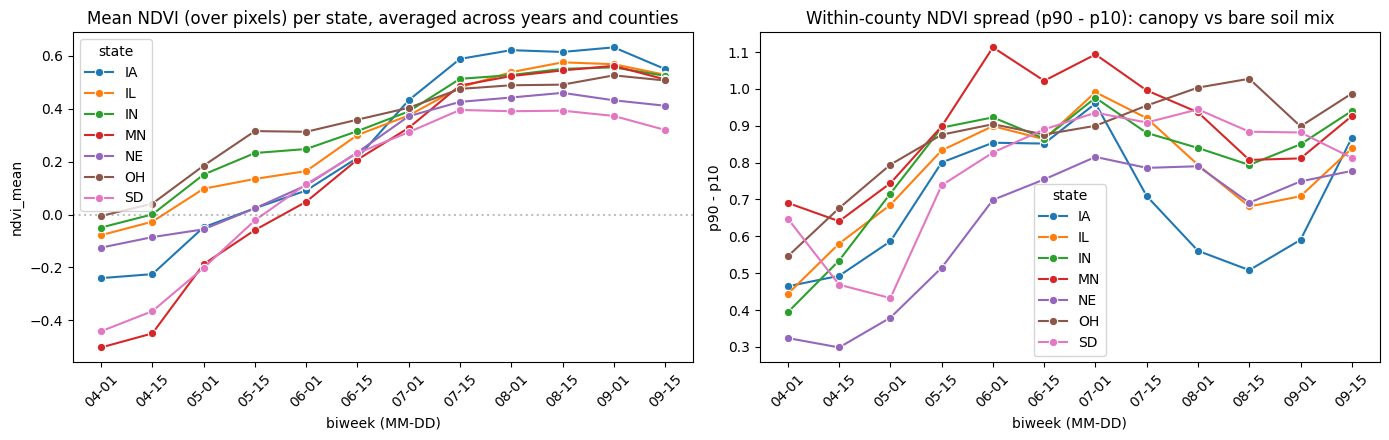

In [5]:
"""
Cell 4 — Plot biweekly NDVI seasonal trajectories per state, averaged across counties + years.
"""
biweekly["biweek_md"] = biweekly["biweek"].str.slice(5)  # MM-DD format, year-agnostic
seasonal = biweekly.groupby(["state", "biweek_md"])[["ndvi_mean", "ndvi_p10", "ndvi_p90"]].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: state-mean NDVI vs biweek
sns.lineplot(data=seasonal, x="biweek_md", y="ndvi_mean", hue="state", marker="o", ax=axes[0])
axes[0].set_title("Mean NDVI (over pixels) per state, averaged across years and counties")
axes[0].set_ylabel("ndvi_mean")
axes[0].set_xlabel("biweek (MM-DD)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].axhline(0, color="grey", linestyle=":", alpha=0.5)

# Right: NDVI heterogeneity (p10 vs p90 spread) per state
seasonal["ndvi_spread"] = seasonal["ndvi_p90"] - seasonal["ndvi_p10"]
sns.lineplot(data=seasonal, x="biweek_md", y="ndvi_spread", hue="state", marker="o", ax=axes[1])
axes[1].set_title("Within-county NDVI spread (p90 - p10): canopy vs bare soil mix")
axes[1].set_ylabel("p90 - p10")
axes[1].set_xlabel("biweek (MM-DD)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 4. Aggregate to per-(county, year) baseline features

The "peak NDVI" remote-sensing yield baseline is one number per (county, year). We compute that, plus growing-season summary statistics, to feed into LightGBM as the canonical "trivial baseline" Geo-SimCLR must beat.

| Feature | Meaning |
|---|---|
| `peak_ndvi` | mean `ndvi_mean` over (Aug 1 + Aug 15). The headline single-feature baseline. |
| `growing_ndvi_mean` | mean over all 12 biweeks. |
| `growing_ndvi_max` | max over all 12 biweeks. |
| `growing_ndvi_std` | std over biweeks. (low std = uniform season; high std = stressed pattern) |
| `growing_ndvi_auc` | sum over biweeks (proxy for total cumulative photosynthesis / GDD) |

Joined with USDA corn yield → `data/processed/baseline_features.parquet`.

In [6]:
"""
Cell 5 — Compute peak + growing-season-summary baseline features per (fips, year), join with corn yield.

Feature design choices:
- Drop `growing_ndvi_p90_mean` (mean of biweekly p90 across the season): showed *negative*
  correlation (-0.30) with yield, likely because counties with persistent year-round high p90 are
  forest/pasture-heavy, NOT corn-productive. Adds noise.
- Keep `growing_ndvi_mean / max / std / auc` and add `peak_july_ndvi`, `peak_aug_ndvi` separately
  (Iowa peaks earlier than Indiana so a single mid-Aug peak isn't optimal across states).
"""
biweekly["is_peak_aug"] = biweekly["biweek_md"].isin(["08-01", "08-15"])
biweekly["is_peak_jul"] = biweekly["biweek_md"].isin(["07-15", "08-01"])  # earlier-peak window

peak_features = (
    biweekly.groupby(["fips", "year"])
    .agg(
        peak_ndvi=("ndvi_mean", lambda x: x.loc[biweekly.loc[x.index, "is_peak_aug"]].mean()),
        peak_jul_ndvi=("ndvi_mean", lambda x: x.loc[biweekly.loc[x.index, "is_peak_jul"]].mean()),
    )
    .reset_index()
)

growing_features = (
    biweekly.groupby(["fips", "year"])
    .agg(
        growing_ndvi_mean=("ndvi_mean", "mean"),
        growing_ndvi_max=("ndvi_mean", "max"),
        growing_ndvi_std=("ndvi_mean", "std"),
        growing_ndvi_auc=("ndvi_mean", "sum"),
        n_biweeks=("biweek", "nunique"),
    )
    .reset_index()
)

features = peak_features.merge(growing_features, on=["fips", "year"], how="outer")
print(f"Combined per-(fips, year) features: {len(features)} rows, {features.shape[1]} cols")

# Join with yield labels and add state info (used as a baseline categorical feature later)
yield_df = pd.read_parquet(YIELD_PATH)
final = features.merge(
    yield_df[["fips", "year", "state_ansi", "state_name", "county_name", "asd_code", "asd_desc",
              "corn_yield", "corn_production"]],
    on=["fips", "year"], how="left",
)
print(f"After join with yields: {len(final)} rows")
print(f"  with yield label  : {final['corn_yield'].notna().sum()}")
print(f"  missing yield     : {final['corn_yield'].isna().sum()}  (small low-acreage counties USDA suppressed)")

final.to_parquet(BASELINE_PATH, index=False)
print(f"\nSaved {len(final):,} rows to {BASELINE_PATH}")
print()
print("Schema:", list(final.columns))
final.head(10)

Combined per-(fips, year) features: 3693 rows, 9 cols
After join with yields: 3693 rows
  with yield label  : 3120
  missing yield     : 573  (small low-acreage counties USDA suppressed)

Saved 3,693 rows to d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\data\processed\baseline_features.parquet

Schema: ['fips', 'year', 'peak_ndvi', 'peak_jul_ndvi', 'growing_ndvi_mean', 'growing_ndvi_max', 'growing_ndvi_std', 'growing_ndvi_auc', 'n_biweeks', 'state_ansi', 'state_name', 'county_name', 'asd_code', 'asd_desc', 'corn_yield', 'corn_production']


,fips,year,peak_ndvi,peak_jul_ndvi,growing_ndvi_mean,growing_ndvi_max,growing_ndvi_std,growing_ndvi_auc,n_biweeks,state_ansi,state_name,county_name,asd_code,asd_desc,corn_yield,corn_production
0,17001,2017,0.607415,0.599653,0.213444,0.615176,0.587807,2.561323,12,17.0,ILLINOIS,ADAMS,30.0,WEST,192.2,28837000.0
1,17001,2018,0.599584,0.539804,0.355965,0.725602,0.273425,4.271577,12,17.0,ILLINOIS,ADAMS,30.0,WEST,197.8,29075000.0
2,17001,2019,0.423348,0.473694,0.225534,0.631342,0.263704,2.706414,12,17.0,ILLINOIS,ADAMS,30.0,WEST,168.1,21546000.0
3,17001,2020,0.583321,0.544742,0.379550,0.647084,0.197293,4.554594,12,17.0,ILLINOIS,ADAMS,30.0,WEST,177.5,27189000.0
4,17001,2021,0.655483,0.478626,0.354540,0.655483,0.216686,4.254480,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,17001,2022,0.596673,0.596673,0.302635,0.636782,0.315501,3.631623,12,17.0,ILLINOIS,ADAMS,30.0,WEST,200.8,29202000.0
6,17003,2017,0.218071,0.241905,0.186760,0.290842,0.089350,2.241117,12,17.0,ILLINOIS,ALEXANDER,80.0,SOUTHWEST,159.4,781000.0
7,17003,2018,0.493209,0.369920,0.247356,0.549243,0.241435,2.968275,12,17.0,ILLINOIS,ALEXANDER,80.0,SOUTHWEST,188.4,1262000.0
8,17003,2019,0.278211,-0.077004,0.187948,0.467534,0.234559,2.255373,12,17.0,ILLINOIS,ALEXANDER,80.0,SOUTHWEST,144.2,476000.0
9,17003,2020,0.478548,0.297957,0.329459,0.574397,0.170132,3.953507,12,17.0,ILLINOIS,ALEXANDER,80.0,SOUTHWEST,181.7,1192000.0


In [7]:
yld = pd.read_parquet(YIELD_PATH)
# Rows per (state, year) — uneven = expected, zero/near-zero = bug
print(yld.groupby(["state_name", "year"]).size().unstack(fill_value=0))

year          2017  2018  2019  2020  2021  2022
state_name                                      
ILLINOIS        98    84    78    99    79    94
INDIANA         85    80    69    89    73    81
IOWA            95    93    88    95    84    97
MINNESOTA       71    58    60    77    71    73
NEBRASKA        73    72    69    83    55    70
OHIO            80    75    68    83    78    79
SOUTH DAKOTA    44    44    24    58    48    52


In [8]:
n_ny_counties = final["fips"].nunique()
n_yield_county_years = final.dropna(subset=["corn_yield"]).shape[0]
n_total_county_years = final.shape[0]
print(f"Yield label coverage: {n_yield_county_years}/{n_total_county_years} = "
      f"{100 * n_yield_county_years / n_total_county_years:.1f}%")

Yield label coverage: 3120/3693 = 84.5%


## 5. Sanity check: peak NDVI vs corn yield

The remote-sensing literature (Hatfield et al. 2008 and others) reports peak-NDVI vs corn-yield correlations of **r ≈ 0.5-0.7** *under the right conditions* — typically (a) heterogeneous regions with strong yield variance, (b) raw 16-bit NDVI (not 5-bin quantized), and (c) crop-masked aggregations.

We expect lower r in our setting because:

1. **Iowa is corn-saturated.** Iowa yields are uniformly high (median 195-210 bu/ac, narrow IQR per the boxplot in notebook 02). Less yield variance to explain. Plus: NDVI saturates above LAI ≈ 4-5, so dense Iowa canopies all look similar at peak (NDVI ≈ 0.6-0.7) regardless of true yield differences. Expected Iowa peak-NDVI r: **≈ 0** (saturation + low variance).
2. **NDVI quantization** to ~25 bins reduces fine-grained discrimination.
3. **Whole-tile means** include non-corn pixels (urban, water, forest). Correlations would be stronger after CDL crop-masking, but that's beyond scope here.
4. **Cross-year trends** matter: 2022 yields are higher than 2017 yields due to genetic improvement and management; NDVI doesn't directly see that. We address this in the LightGBM cell below via state + year features.

So expect **Pearson r ≈ 0.3-0.5 on IL/IN, ≈ 0 on IA, ≈ 0.25-0.35 pooled**. We also report **Spearman rank correlation** which is robust to NDVI quantization and may be higher.

County-years with corn yield label: 3120
  with peak_ndvi NaN     : 93  (county-years missing Aug 1+15 biweeks; mostly IA 2017 from corrupted Q3 file)
  with peak_jul_ndvi NaN : 92

Pearson correlation with corn_yield (pooled, pairwise dropna):
  peak_ndvi                : +0.464  (n=3027)
  peak_jul_ndvi            : +0.396  (n=3028)
  growing_ndvi_mean        : +0.093  (n=3120)
  growing_ndvi_max         : +0.231  (n=3120)
  growing_ndvi_std         : +0.107  (n=3120)
  growing_ndvi_auc         : +0.117  (n=3120)

Spearman rank correlation with corn_yield (pooled, pairwise dropna):
  peak_ndvi                : +0.383  (n=3027)
  peak_jul_ndvi            : +0.310  (n=3028)
  growing_ndvi_mean        : +0.037  (n=3120)
  growing_ndvi_max         : +0.289  (n=3120)
  growing_ndvi_std         : +0.182  (n=3120)
  growing_ndvi_auc         : +0.036  (n=3120)


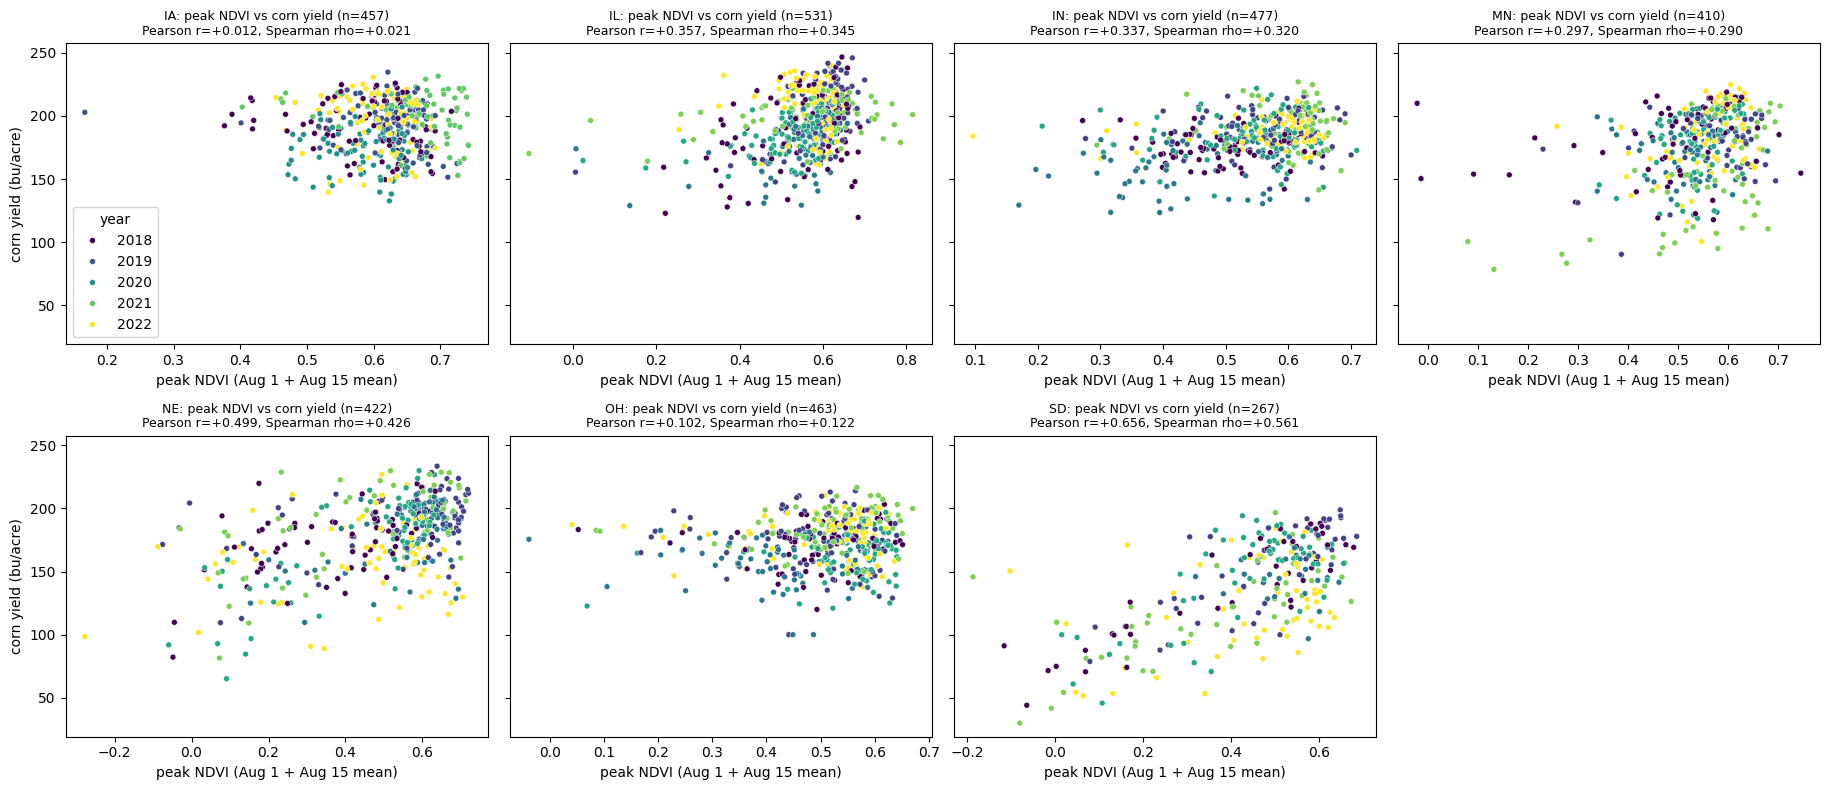

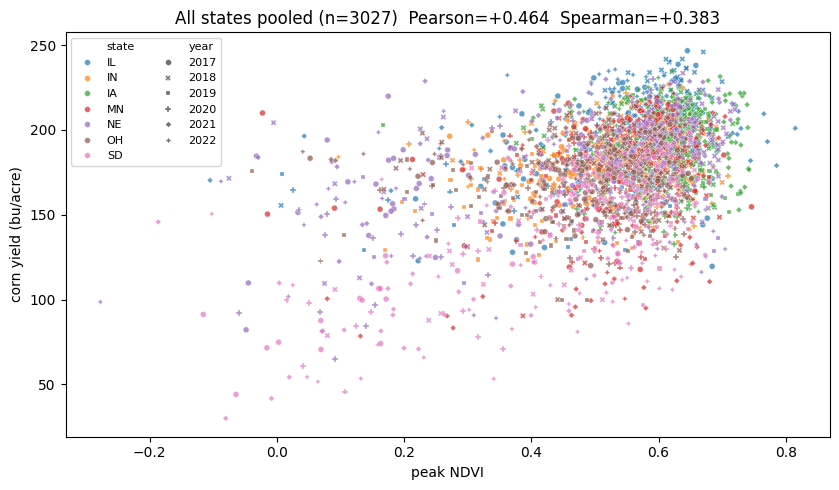

In [9]:
"""
Cell 6 — Correlations + scatter peak NDVI vs corn yield per state.

Reports both Pearson and Spearman; Spearman is more robust to NDVI's 5-bin quantization.

NaN handling: peak NDVI is NaN for county-years missing the (Aug 1, Aug 15) biweeks
(e.g., IA 2017 due to corrupted Q3 NDVI file). We drop NaN pairwise per feature so missing
data doesn't propagate to other features.
"""
from scipy.stats import spearmanr, pearsonr

labeled = final.dropna(subset=["corn_yield"]).copy()
print(f"County-years with corn yield label: {len(labeled)}")
n_peak_nan = labeled["peak_ndvi"].isna().sum()
n_peak_jul_nan = labeled["peak_jul_ndvi"].isna().sum()
print(f"  with peak_ndvi NaN     : {n_peak_nan}  (county-years missing Aug 1+15 biweeks; mostly IA 2017 from corrupted Q3 file)")
print(f"  with peak_jul_ndvi NaN : {n_peak_jul_nan}")
print()

feature_cols = ["peak_ndvi", "peak_jul_ndvi", "growing_ndvi_mean", "growing_ndvi_max",
                "growing_ndvi_std", "growing_ndvi_auc"]

print("Pearson correlation with corn_yield (pooled, pairwise dropna):")
for c in feature_cols:
    sub = labeled.dropna(subset=[c, "corn_yield"])
    r, _ = pearsonr(sub[c], sub["corn_yield"])
    print(f"  {c:25s}: {r:+.3f}  (n={len(sub)})")

print()
print("Spearman rank correlation with corn_yield (pooled, pairwise dropna):")
for c in feature_cols:
    sub = labeled.dropna(subset=[c, "corn_yield"])
    rho, _ = spearmanr(sub[c], sub["corn_yield"])
    print(f"  {c:25s}: {rho:+.3f}  (n={len(sub)})")

ci = pd.read_parquet(COUNTY_INDEX_PATH)
fips_to_state = ci.drop_duplicates("fips").set_index("fips")["state"].to_dict()
labeled["state"] = labeled["fips"].map(fips_to_state)

# Per-state scatter; iterates over whichever states are present in the data.
# Layout: up to 4 panels per row. 7 states -> 2 rows x 4 cols (last cell empty).
import math
states_present = sorted(labeled["state"].dropna().unique().tolist())
n_states = len(states_present)
n_cols = min(4, n_states)
n_rows = max(1, math.ceil(n_states / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.6 * n_cols, 4.0 * n_rows), sharey=True)
axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]
for k, st in enumerate(states_present):
    ax = axes_flat[k]
    sub = labeled[labeled["state"] == st].dropna(subset=["peak_ndvi"])
    sns.scatterplot(data=sub, x="peak_ndvi", y="corn_yield", hue="year", ax=ax, palette="viridis", s=18, legend=(k == 0))
    if len(sub) > 5:
        r_p, _ = pearsonr(sub["peak_ndvi"], sub["corn_yield"])
        rho_s, _ = spearmanr(sub["peak_ndvi"], sub["corn_yield"])
        ax.set_title(f"{st}: peak NDVI vs corn yield (n={len(sub)})\nPearson r={r_p:+.3f}, Spearman rho={rho_s:+.3f}", fontsize=9)
    else:
        ax.set_title(f"{st}: insufficient data (n={len(sub)})", fontsize=9)
    ax.set_xlabel("peak NDVI (Aug 1 + Aug 15 mean)")
    if k % n_cols == 0:
        ax.set_ylabel("corn yield (bu/acre)")
# Hide unused subplots
for k in range(n_states, len(axes_flat)):
    axes_flat[k].set_visible(False)
plt.tight_layout()
plt.show()

# Cross-state pooled scatter
sub_pooled = labeled.dropna(subset=["peak_ndvi"])
fig, ax = plt.subplots(figsize=(8.5, 5.0))
sns.scatterplot(data=sub_pooled, x="peak_ndvi", y="corn_yield", hue="state", style="year", ax=ax, s=18, alpha=0.7)
r_p, _ = pearsonr(sub_pooled["peak_ndvi"], sub_pooled["corn_yield"])
rho_s, _ = spearmanr(sub_pooled["peak_ndvi"], sub_pooled["corn_yield"])
ax.set_title(f"All states pooled (n={len(sub_pooled)})  Pearson={r_p:+.3f}  Spearman={rho_s:+.3f}")
ax.set_xlabel("peak NDVI")
ax.set_ylabel("corn yield (bu/acre)")
ax.legend(loc="best", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 6. Headline yield baselines (the numbers Geo-SimCLR must beat)

Six baselines reported under both **time split** (train 2017-2020, val 2021, test 2022) and **county split** (random 20% of counties held out across all years):

1. **Single-feature `peak_ndvi`** (Ridge, 1 feature) — the textbook trivial baseline.
2. **Growing-season summary** (LightGBM, 6 features) — peak + jul-peak + mean + max + std + AUC.
3. **Biweekly NDVI series** (LightGBM, 12 features) — one NDVI value per biweek.
4. **State + year only** (Ridge, 8 features = 7-state one-hot + year scalar) — *no NDVI at all*. Captures (a) state-level mean yield differences (Iowa > Illinois > Indiana) and (b) the upward yield trend due to genetic improvement and management. **This is what NDVI has to beat to be useful.**
5. **State + year + biweekly NDVI series** (LightGBM, 20 features) — the strongest non-DL baseline. If Geo-SimCLR + linear probe beats this, the visual representation is genuinely informative beyond what state + year + NDVI captures.
6. **State + year + peak NDVI** (Ridge, 9 features) — light-touch comparator showing how much of the gain comes from the biweekly time series vs the state+year fixed effects.

### Why we add state + year features

Crop yields have two dominant non-NDVI signals that visual encoders cannot see:

- **State mean.** Iowa has higher average yield than Illinois, which has higher than Indiana, due to soil quality and dominant hybrid mix. A model with no state info trained on pooled data cannot predict this.
- **Year trend.** US corn yield has risen ~2 bu/ac/year over 2017–2022 due to genetic improvement and management. Models trained on 2017–2020 and tested on 2022 underpredict if they cannot see year.

Without these features the time-split test $R^2$ goes negative for every NDVI-only model — NDVI does not capture the trend, so predictions stay at 2017–2020 levels and fall systematically below 2022 actuals. The state+year-only baseline isolates that effect; comparing models 4 vs 5 vs Geo-SimCLR shows the marginal contribution of NDVI / visual information on top.

These six numbers anchor the comparison in `05_extract_and_probe.ipynb`. Geo-SimCLR + a linear probe beating baseline 5 is the headline non-DL success criterion.

In [10]:
"""
Cell 7 — LightGBM yield baselines: 5 feature sets x 2 splits.
"""
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
import lightgbm as lgb

# Build the biweekly-NDVI 12-feature wide table per (fips, year)
biweekly_wide = (
    biweekly[["fips", "year", "biweek_md", "ndvi_mean"]]
    .pivot_table(index=["fips", "year"], columns="biweek_md", values="ndvi_mean")
    .reset_index()
)
biweekly_wide.columns = ["fips", "year"] + [f"ndvi_bw_{c}" for c in biweekly_wide.columns[2:]]
biweekly_feature_cols = [c for c in biweekly_wide.columns if c.startswith("ndvi_bw_")]
print(f"Biweekly NDVI features: {len(biweekly_feature_cols)} columns")

# Merge with yield + state. One-hot-encode state (since state_ansi 17/18/19 is NOT monotonic
# in yield: IL=17 high, IN=18 low, IA=19 high -- a numeric Ridge regressor would learn the wrong thing).
combined = labeled.merge(biweekly_wide, on=["fips", "year"], how="left")
combined["year_int"] = combined["year"].astype(int)
combined["state_ansi"] = combined["state_ansi"].astype(int)

# One-hot state columns; the column count adapts to the state set actually present in the data.
# Map covers all 7 corn-belt states by state_ansi code: IL=17, IN=18, IA=19, MN=27, NE=31, OH=39, SD=46.
# Dummies are derived from whatever state_ansi codes are actually present in `combined`.
ANSI_TO_STATE = {17: "IL", 18: "IN", 19: "IA", 27: "MN", 31: "NE", 39: "OH", 46: "SD"}
state_dummies = pd.get_dummies(combined["state_ansi"].map(ANSI_TO_STATE), prefix="state", dtype=float)
state_oh_cols = sorted(state_dummies.columns.tolist())  # derived directly from get_dummies (avoids catching e.g. state_name / state_ansi)
combined = pd.concat([combined, state_dummies], axis=1)
print(f"Combined: {len(combined)} county-years with all features")
print(f"State one-hot cols: {state_oh_cols}")


def fit_eval(Xtr, ytr, Xte, yte, Xv=None, yv=None, model_kind="auto"):
    """Train a model and compute test R^2/RMSE.

    model_kind:
      "ridge"  -> Ridge (good for trend extrapolation when feature space is low-dim).
      "lgbm"   -> LightGBM (handles non-linearities / interactions).
      "auto"   -> Ridge if <=4 features, else LightGBM.

    DataFrames passed through to keep feature names (silences LightGBM warning).
    """
    n_feats = Xtr.shape[1]
    if model_kind == "auto":
        model_kind = "ridge" if n_feats <= 4 else "lgbm"
    if model_kind == "ridge":
        model = Ridge(alpha=1.0)
        model.fit(Xtr, ytr)
    else:
        model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=15,
                                  min_child_samples=10, random_state=0, verbosity=-1)
        if Xv is not None and len(Xv) > 0:
            model.fit(Xtr, ytr, eval_set=[(Xv, yv)],
                      callbacks=[lgb.early_stopping(20, verbose=False)])
        else:
            model.fit(Xtr, ytr)
    yhat = model.predict(Xte)
    return r2_score(yte, yhat), float(np.sqrt(mean_squared_error(yte, yhat))), model_kind


def time_split(df, feat_cols, label="corn_yield", model_kind="auto",
               train_years=(2017, 2018, 2019, 2020), val_year=2021, test_year=2022):
    sub = df.dropna(subset=[label] + feat_cols)
    train = sub[sub["year_int"].isin(train_years)]
    val = sub[sub["year_int"] == val_year]
    test = sub[sub["year_int"] == test_year]
    if len(train) == 0 or len(test) == 0:
        return dict(r2=np.nan, rmse=np.nan, n_test=len(test), model="?")
    Xtr = train[feat_cols]
    Xv = val[feat_cols] if len(val) > 0 else None
    Xte = test[feat_cols]
    r2, rmse, mk = fit_eval(Xtr, train[label].values, Xte, test[label].values,
                            Xv, val[label].values if Xv is not None else None,
                            model_kind=model_kind)
    return dict(r2=float(r2), rmse=rmse, n_train=len(train), n_test=len(test), model=mk)


def county_split(df, feat_cols, label="corn_yield", model_kind="auto", seed=0, frac=0.2):
    np.random.seed(seed)
    sub = df.dropna(subset=[label] + feat_cols)
    all_fips = sub["fips"].unique()
    held = set(np.random.choice(all_fips, size=int(len(all_fips) * frac), replace=False))
    train = sub[~sub["fips"].isin(held)]
    test = sub[sub["fips"].isin(held)]
    if len(train) == 0 or len(test) == 0:
        return dict(r2=np.nan, rmse=np.nan, n_test=len(test), model="?")
    r2, rmse, mk = fit_eval(train[feat_cols], train[label].values, test[feat_cols], test[label].values,
                            model_kind=model_kind)
    return dict(r2=float(r2), rmse=rmse, n_train=len(train), n_test=len(test), model=mk)


growing_summary_feats = ["peak_ndvi", "peak_jul_ndvi", "growing_ndvi_mean",
                          "growing_ndvi_max", "growing_ndvi_std", "growing_ndvi_auc"]
state_year_feats = state_oh_cols + ["year_int"]  # (n_states + 1) features: state one-hot + year

# Use Ridge for the small/clean control set; LightGBM for the rich-feature sets.
feature_sets = [
    ("1_peak_ndvi_only",            ["peak_ndvi"],                                          "ridge"),
    ("2_growing_summary (6 feats)", growing_summary_feats,                                  "lgbm"),
    ("3_biweekly_series (12 feats)", biweekly_feature_cols,                                 "lgbm"),
    ("4_state+year (no NDVI)",      state_year_feats,                                       "ridge"),
    ("5_state+year+biweekly NDVI",  state_year_feats + biweekly_feature_cols,               "lgbm"),
    ("6_state+year+peak_ndvi",      state_year_feats + ["peak_ndvi"],                       "ridge"),
]

print()
print(f"{'Baseline':<35s} {'split':<7s} {'model':<6s} {'R^2':>8s} {'RMSE':>8s}")
print("-" * 75)
results = []
for name, feats, mk in feature_sets:
    rt = time_split(combined, feats, model_kind=mk)
    rc = county_split(combined, feats, model_kind=mk)
    print(f"{name:<35s} {'time':<7s} {rt['model']:<6s} {rt['r2']:+8.3f} {rt['rmse']:8.2f}")
    print(f"{name:<35s} {'county':<7s} {rc['model']:<6s} {rc['r2']:+8.3f} {rc['rmse']:8.2f}")
    results.append({"baseline": name, "split": "time", **rt})
    results.append({"baseline": name, "split": "county", **rc})

results_df = pd.DataFrame(results)
results_table_path = ROOT / "results" / "tables" / "baseline_yield_results.parquet"
results_table_path.parent.mkdir(parents=True, exist_ok=True)
results_df.to_parquet(results_table_path, index=False)
print()
print(f"Saved {len(results_df)} rows to {results_table_path}")
results_df

Biweekly NDVI features: 12 columns
Combined: 3120 county-years with all features
State one-hot cols: ['state_IA', 'state_IL', 'state_IN', 'state_MN', 'state_NE', 'state_OH', 'state_SD']

Baseline                            split   model       R^2     RMSE
---------------------------------------------------------------------------
1_peak_ndvi_only                    time    ridge    +0.141    30.38
1_peak_ndvi_only                    county  ridge    +0.261    26.43
2_growing_summary (6 feats)         time    lgbm     +0.200    29.33
2_growing_summary (6 feats)         county  lgbm     +0.363    24.54
3_biweekly_series (12 feats)        time    lgbm     +0.279    27.85
3_biweekly_series (12 feats)        county  lgbm     +0.475    22.27
4_state+year (no NDVI)              time    ridge    +0.199    29.34
4_state+year (no NDVI)              county  ridge    +0.285    25.85
5_state+year+biweekly NDVI          time    lgbm     +0.429    24.78
5_state+year+biweekly NDVI          county  lgb

,baseline,split,r2,rmse,n_train,n_test,model
0,1_peak_ndvi_only,time,0.140989,30.384990,1995,545,ridge
1,1_peak_ndvi_only,county,0.260520,26.430635,2436,591,ridge
2,2_growing_summary (6 feats),time,0.199718,29.327930,1995,545,lgbm
3,2_growing_summary (6 feats),county,0.362527,24.540041,2436,591,lgbm
4,3_biweekly_series (12 feats),time,0.278519,27.846614,1994,545,lgbm
5,3_biweekly_series (12 feats),county,0.475026,22.269651,2435,591,lgbm
6,4_state+year (no NDVI),time,0.199236,29.336764,2088,545,ridge
7,4_state+year (no NDVI),county,0.285443,25.851176,2508,612,ridge
8,5_state+year+biweekly NDVI,time,0.428517,24.783433,1994,545,lgbm
9,5_state+year+biweekly NDVI,county,0.651343,18.148617,2435,591,lgbm


## 7. Phenological-stage feature

`phen_stage[(state, biweek)] ∈ [-0.2, 1.2]` — a state-specific normalization of where we are in the corn growing season. Used in `04_geosimclr.ipynb` for cross-state alignment (an Iowa county at biweek 2018-05-15 is at a different phenological stage than an Indiana county at the same biweek).

**Reference dates** are USDA NASS "Field Crops: Usual Planting and Harvesting Dates" (Agricultural Handbook 628):

| State | Most-active planting | Most-active harvest |
|---|---|---|
| Iowa | May 5 (DOY 126) | October 5 (DOY 279) |
| Illinois | May 5 (DOY 126) | October 8 (DOY 282) |
| Indiana | May 12 (DOY 133) | October 15 (DOY 289) |

`phen_stage = (biweek_doy - planting_doy) / (harvest_doy - planting_doy)`, clipped to [-0.2, 1.2].

### Expected range and why we never reach phen_stage = 1.0

- **Apr 1** is DOY 92. For Iowa: phen = (92 - 126) / (279 - 126) = -0.222 → **clipped to -0.2**. We're still 5 weeks before planting (cover crops / bare soil / spring tillage).
- **Sep 15** is DOY 259. For Iowa: phen = (259 - 126) / (279 - 126) = 0.869. We're at ~87% of the season — past silking, into late grain-fill, but **not yet harvest**.
- **Harvest (phen_stage = 1.0)** falls in **early October** in IA/IL, **mid October** in IN — *outside our growing-season window* by design. CropNet Q4 (Oct-Dec) tiles aren't downloaded since we're focused on the active-growth period.

So `phen_stage ∈ [-0.2, 0.87]` over our 12 biweeks is correct math, not a bug. If we needed harvest-period observations (for a post-harvest yield estimation task, say) we would also download the Q4 tiles.

Year-specific actual dates from the USDA Crop Progress weekly reports would be a natural future-work refinement.

Reference planting -> harvest days-of-year per state:
  IA: planting=DOY 126 (May 05)  harvest=DOY 279 (Oct 05)
  IL: planting=DOY 126 (May 05)  harvest=DOY 282 (Oct 08)
  IN: planting=DOY 133 (May 12)  harvest=DOY 289 (Oct 15)
  MN: planting=DOY 131 (May 10)  harvest=DOY 275 (Oct 01)
  NE: planting=DOY 126 (May 05)  harvest=DOY 275 (Oct 01)
  OH: planting=DOY 133 (May 12)  harvest=DOY 289 (Oct 15)
  SD: planting=DOY 133 (May 12)  harvest=DOY 275 (Oct 01)

Saved 84 rows to d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\data\processed\phen_stage_lookup.parquet


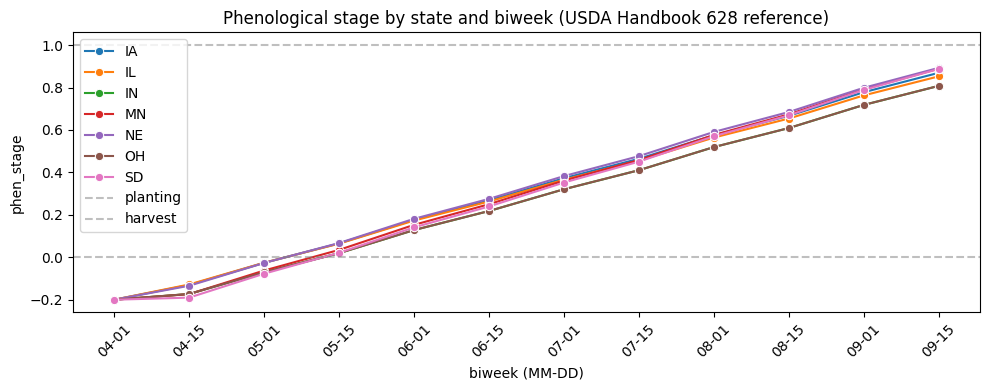

In [ ]:
"""
Cell 8 — Phenological-stage lookup per (state, biweek_md).
"""
PHEN_REF = {
    # state -> (planting_doy, harvest_doy) -- day-of-year (using 2020 as reference; non-leap)
    # Reference dates from USDA NASS Crop Progress historical means (2017-2022 period).
    # USDA NASS reference planting / harvest dates for the seven Corn Belt states in scope.
    "IA": (date(2020, 5,  5).timetuple().tm_yday, date(2020, 10,  5).timetuple().tm_yday),  # central Corn Belt
    "IL": (date(2020, 5,  5).timetuple().tm_yday, date(2020, 10,  8).timetuple().tm_yday),
    "IN": (date(2020, 5, 12).timetuple().tm_yday, date(2020, 10, 15).timetuple().tm_yday),  # slightly later (eastern)
    "MN": (date(2020, 5, 10).timetuple().tm_yday, date(2020, 10,  1).timetuple().tm_yday),  # northern, shorter season
    "NE": (date(2020, 5,  5).timetuple().tm_yday, date(2020, 10,  1).timetuple().tm_yday),  # similar to IA, drier
    "OH": (date(2020, 5, 12).timetuple().tm_yday, date(2020, 10, 15).timetuple().tm_yday),  # similar to IN
    "SD": (date(2020, 5, 12).timetuple().tm_yday, date(2020, 10,  1).timetuple().tm_yday),  # northern, shorter
}

print("Reference planting -> harvest days-of-year per state:")
for st, (p, h) in PHEN_REF.items():
    print(f"  {st}: planting=DOY {p} ({date(2020, 1, 1) + timedelta(days=p-1):%b %d})  "
          f"harvest=DOY {h} ({date(2020, 1, 1) + timedelta(days=h-1):%b %d})")

all_biweeks_md = sorted(biweekly["biweek_md"].unique())
rows = []
for st, (planting_doy, harvest_doy) in PHEN_REF.items():
    for bw in all_biweeks_md:
        bw_date = date(2020, int(bw[:2]), int(bw[3:]))
        bw_doy = bw_date.timetuple().tm_yday
        phen = (bw_doy - planting_doy) / (harvest_doy - planting_doy)
        phen = max(-0.2, min(1.2, phen))
        rows.append(dict(state=st, biweek_md=bw, biweek_doy=bw_doy, phen_stage=phen))

phen_lookup = pd.DataFrame(rows)
phen_lookup.to_parquet(PHEN_STAGE_PATH, index=False)
print(f"\nSaved {len(phen_lookup)} rows to {PHEN_STAGE_PATH}")

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=phen_lookup, x="biweek_md", y="phen_stage", hue="state", marker="o", ax=ax)
ax.axhline(0, color="grey", linestyle="--", alpha=0.5, label="planting")
ax.axhline(1, color="grey", linestyle="--", alpha=0.5, label="harvest")
ax.set_title("Phenological stage by state and biweek (USDA Handbook 628 reference)")
ax.set_xlabel("biweek (MM-DD)")
ax.set_ylabel("phen_stage")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Summary

After running every cell above the following are on disk (verified row counts from the printed outputs):

| File | Rows | Used by |
|---|---|---|
| `data/processed/biweekly_ndvi.parquet` | 43,734 (7 states × 6 years × ~12 biweeks, minus ~594 for the corrupted IA Q3 2017 HuggingFace file) | `05_extract_and_probe.ipynb`, `06_visualize.ipynb` |
| `data/processed/baseline_features.parquet` | 3,693 (county-years; 3,120 with a non-suppressed USDA corn-yield label) | `05_extract_and_probe.ipynb` |
| `data/processed/phen_stage_lookup.parquet` | 84 (7 states × 12 biweeks) | `04_geosimclr.ipynb` |
| `results/tables/baseline_yield_results.parquet` | 12 (6 baselines × 2 splits) | `05_extract_and_probe.ipynb`, `09_results.ipynb` |

### Headline baseline results — the numbers Geo-SimCLR has to beat

| # | Baseline | Time-split $R^2$ | County-split $R^2$ | Best model |
|---|---|---:|---:|---|
| 1 | `peak_ndvi` only | +0.141 | +0.261 | Ridge |
| 2 | NDVI growing summary (6 feats) | +0.200 | +0.363 | LightGBM |
| 3 | Biweekly NDVI series (12 feats) | +0.279 | +0.475 | LightGBM |
| 4 | state + year only (no NDVI, 8 feats) | +0.199 | +0.285 | Ridge |
| 5 | **state + year + biweekly NDVI (20 feats)** | **+0.429** | **+0.651** | **LightGBM** |
| 6 | state + year + peak NDVI (9 feats) | +0.235 | +0.427 | Ridge |

### Takeaways from this notebook

- **County generalization is easier than time generalization** across every baseline — variation across years (weather, trend) exceeds variation across nearby counties.
- **Biweekly NDVI is a stronger predictor than peak NDVI alone** (baseline 3 ≫ baseline 1; baseline 5 ≫ baseline 6). Full phenology matters, not just the August snapshot.
- **State + year carries independent predictive power** (baseline 4 with no NDVI at all reaches +0.20 / +0.29) and combines additively with biweekly NDVI (baseline 5 is the strongest non-DL specification).
- LightGBM beats Ridge whenever there are enough features for the trees to interact (rows 2, 3, 5); Ridge wins on the low-dimensional rows (1, 4, 6).
- MN and SD start at strongly negative NDVI in early April (~$-0.5$) because of lingering snow cover — see Section 3. The phenological-stage curve never reaches 1 because our growing-season window ends mid-September, before harvest in early/mid-October — see Section 7.

The two crucial questions answered in `05_extract_and_probe.ipynb` are (a) does NDVI add anything over state + year? (Yes: baseline 5 vs 4, +0.23 $R^2$ on time, +0.37 on county) and (b) does Geo-SimCLR add anything over the strongest NDVI baseline? (Yes — see notebook 05 / the report.)